# Macroeconomic Stress Testing and Model Drift Analysis

This notebook ingests LendingClub loan data, trains baseline and challenger credit risk models (Logistic Regression and LightGBM), and evaluates their stability under simulated macroeconomic stress. 

We will specifically look at **Population Stability Index (PSI)** to measure model drift and standard classification metrics (AUC, KS Statistic, Brier Score) to evaluate predictive degradation.

In [69]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ks_2samp
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss, roc_curve
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler

# Set visualization styles
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')

## 1. Data Ingestion & Chronological Splitting
We load the historical loan data, engineer our `default` target variable, and split the data chronologically (80% In-Time for training/testing, 20% Out-of-Time for stress testing).

In [70]:
def load_and_prep_lendingclub(filepath='loan.csv'):
    print(f"Loading dataset from '{filepath}'...")
    
    # 1. Define all necessary columns (including new high-impact features)
    usecols = ['issue_d', 'loan_status', 'dti', 'fico_range_low', 
               'annual_inc', 'revol_util', 'loan_amnt', 'int_rate', 'term',
               'installment', 'purpose', 'home_ownership', 'emp_length', 
               'inq_last_6mths', 'earliest_cr_line']
    
    try:
        df = pd.read_csv(filepath, usecols=usecols)
    except FileNotFoundError:
        print(f"File {filepath} not found. Please ensure it is in the correct directory.")
        return None, None, None

    # 2. Filter statuses and create binary target
    valid_statuses = ['Fully Paid', 'Charged Off', 'Default']
    df = df[df['loan_status'].isin(valid_statuses)].copy()
    df['default'] = np.where(df['loan_status'] == 'Fully Paid', 0, 1)

    # 3. Clean string columns into numerics
    df['term'] = df['term'].str.extract(r'(\d+)').astype(float)
    df['emp_length'] = df['emp_length'].astype(str).str.extract(r'(\d+)').astype(float)
    df['emp_length'] = df['emp_length'].fillna(0) # Assume 0 years if missing
    
    for col in ['revol_util', 'int_rate']:
        if col in df.columns and df[col].dtype == 'O':
            df[col] = df[col].str.rstrip('%').astype(float)
            
    # 4. Handle Dates & Sort chronologically
    df['issue_d'] = pd.to_datetime(df['issue_d'])
    df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])
    
    df = df.sort_values('issue_d').reset_index(drop=True)
    
    # 5. Feature Engineering (Financial Ratios)
    df['credit_hist_months'] = (df['issue_d'] - df['earliest_cr_line']).dt.days / 30.4
    df['install_inc_ratio'] = df['installment'] / (df['annual_inc'] / 12 + 1)
    df['loan_to_inc'] = df['loan_amnt'] / (df['annual_inc'] + 1)
    
    # 6. Categorical Encoding (One-Hot Encoding)
    # Added dtype=int to ensure we get 1/0 instead of True/False
    df = pd.get_dummies(df, columns=['purpose', 'home_ownership'], drop_first=True, dtype=int)
    
    # Define continuous features that require scaling
    features_to_scale = [
        'dti', 'fico_range_low', 'annual_inc', 'revol_util', 'loan_amnt', 
        'int_rate', 'term', 'installment', 'emp_length', 'inq_last_6mths', 
        'credit_hist_months', 'install_inc_ratio', 'loan_to_inc'
    ]
    
    # Drop rows with missing values in our critical features
    df = df.dropna(subset=['issue_d', 'default'] + features_to_scale)
    
    # 7. 80/20 Chronological Split
    split_idx = int(len(df) * 0.8)
    df_in_time = df.iloc[:split_idx].copy()
    df_oot = df.iloc[split_idx:].copy()

    # Print data info BEFORE dropping date columns
    print(f"In-Time records: {len(df_in_time):,} | Out-Of-Time records: {len(df_oot):,}")
    print(f"In-Time Period:     {df_in_time['issue_d'].min().strftime('%Y-%m-%d')} to {df_in_time['issue_d'].max().strftime('%Y-%m-%d')}")
    print(f"Out-Of-Time Period: {df_oot['issue_d'].min().strftime('%Y-%m-%d')} to {df_oot['issue_d'].max().strftime('%Y-%m-%d')}")

    # 8. Drop unnecessary columns
    cols_to_drop = ["issue_d", "loan_status", "earliest_cr_line"]
    df_in_time.drop(columns=cols_to_drop, inplace=True)
    df_oot.drop(columns=cols_to_drop, inplace=True)
    
    
    # Get final list of all feature names (scaled numericals + one-hot binaries)
    all_features = [col for col in df_in_time.columns if col != 'default']
    
    return df_in_time, df_oot, all_features

# Execute pipeline
df_in_time, df_oot, all_features = load_and_prep_lendingclub('loan.csv')

Loading dataset from 'loan.csv'...
In-Time records: 1,075,295 | Out-Of-Time records: 268,824
In-Time Period:     2007-06-01 to 2016-10-01
Out-Of-Time Period: 2016-10-01 to 2018-12-01


In [71]:
df_in_time.head()

,loan_amnt,term,int_rate,installment,emp_length,annual_inc,dti,fico_range_low,inq_last_6mths,revol_util,...,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT
0,7500.0,36.0,13.75,255.43,1.0,22000.0,14.29,660.0,0.0,51.5,...,0,0,0,0,0,0,0,0,1,0
1,3500.0,36.0,10.28,113.39,1.0,20000.0,1.50,680.0,0.0,32.4,...,0,0,0,0,0,0,0,0,0,1
2,5750.0,36.0,7.43,178.69,10.0,125000.0,0.27,790.0,0.0,10.2,...,0,0,0,0,0,1,0,0,0,0
3,5000.0,36.0,7.43,155.38,6.0,40000.0,2.55,770.0,2.0,14.0,...,0,0,0,0,0,0,0,0,0,1
4,1200.0,36.0,11.54,39.60,1.0,20000.0,2.04,660.0,2.0,75.8,...,0,0,0,0,0,0,0,0,0,1


### 1.1 Exploratory Data Analysis
Let's visualize the distribution of our target variable (`default`) in the training set to understand the class imbalance.

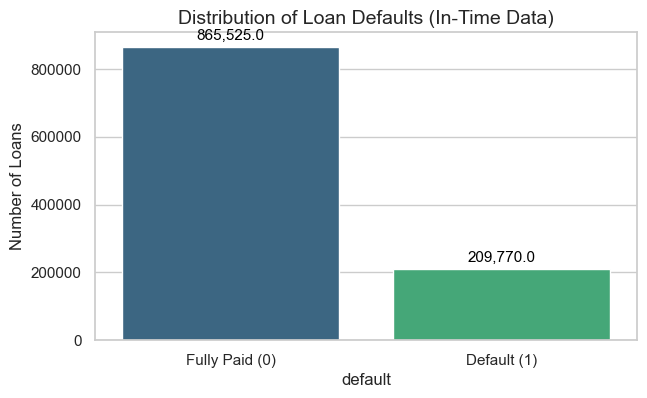

In [72]:
if df_in_time is not None:
    plt.figure(figsize=(7, 4))
    ax = sns.countplot(x=df_in_time['default'], palette='viridis')
    plt.title('Distribution of Loan Defaults (In-Time Data)', fontsize=14)
    plt.xticks([0, 1], ['Fully Paid (0)', 'Default (1)'])
    plt.ylabel('Number of Loans')
    
    # Add counts on top of bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height():,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                    textcoords='offset points')
    plt.show()

## 2. Metrics & Drift Calculations
We define custom functions to calculate classification metrics (AUC, KS, Brier Score) and the **Population Stability Index (PSI)**, which alerts us if the distribution of model predictions shifts significantly when applied to new or stressed data.

In [73]:
def calculate_psi(expected, actual, bins=10):
    quantiles = np.linspace(0, 100, bins + 1)
    bin_edges = np.percentile(expected, quantiles)
    bin_edges = np.unique(bin_edges) 
    
    if len(bin_edges) < 2:
        return 0.0

    bin_edges[0] -= 1e-5
    bin_edges[-1] += 1e-5

    expected_counts = np.histogram(expected, bins=bin_edges)[0]
    actual_counts = np.histogram(actual, bins=bin_edges)[0]

    expected_pct = np.where(expected_counts == 0, 1e-4, expected_counts / len(expected))
    actual_pct = np.where(actual_counts == 0, 1e-4, actual_counts / len(actual))

    return float(np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct)))

def evaluate_model(y_true, y_prob):
    auc = roc_auc_score(y_true, y_prob)
    ks_stat, _ = ks_2samp(y_prob[y_true == 1], y_prob[y_true == 0])
    return {
        'AUC': round(float(auc), 4),
        'KS_Stat': round(float(ks_stat), 4),
        'Brier_Score': round(float(brier_score_loss(y_true, y_prob)), 4),
    }

def print_psi_verdict(name, psi):
    if psi >= 0.26:
        print(f"🔴 CRITICAL [{name}]: PSI = {psi:.4f} (Major shift detected)")
    elif psi >= 0.10:
        print(f"🟡 WARNING  [{name}]: PSI = {psi:.4f} (Moderate shift detected)")
    else:
        print(f"🟢 STABLE   [{name}]: PSI = {psi:.4f} (No significant shift)")

## 3. Pipeline Setup & Model Training
We will build and train two models on the in-time data:
1. **Logistic Regression (Baseline):** Features are discretized into 5 bins to enforce strict stability.
2. **LightGBM (Challenger):** A tree-based boosting model that captures non-linear relationships.

In [74]:
if df_in_time is not None:
    X_train, X_oos, y_train, y_oos = train_test_split(
        df_in_time.drop(columns=['default']), df_in_time['default'], test_size=0.25, random_state=42
    )
    X_oot, y_oot = df_oot.drop(columns=['default']), df_oot['default']
    
    print("--- Training Models ---")
    
    # 2. Logistic Regression Pipeline
    # FIXED: Increased n_bins to 15 so we don't lose the predictive power in the extremes (tails)
    lr_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('binner', KBinsDiscretizer(n_bins=15, encode='onehot', strategy='quantile')),
        ('classifier', LogisticRegression(C=0.1, penalty='l2', max_iter=1000, random_state=42))
    ])
    lr_pipeline.fit(X_train, y_train)
    print("✅ Logistic Regression Trained")
    
    # 3. LightGBM Pipeline
    lgb_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('classifier', lgb.LGBMClassifier(
            n_estimators=300,        
            learning_rate=0.05,      
            max_depth=5,             
            num_leaves=31,           
            min_child_samples=50,    
            random_state=42, 
            verbosity=-1, 
            class_weight='balanced'
        ))
    ])
    lgb_pipeline.fit(X_train, y_train)
    print("✅ LightGBM Trained")
    
    # Generate Training Probabilities for Baseline PSI reference
    lr_prob_train = lr_pipeline.predict_proba(X_train)[:, 1]
    lgb_prob_train = lgb_pipeline.predict_proba(X_train)[:, 1]
    
    # Evaluate on standard (unshocked) OOT data
    print("\n--- Standard Out-Of-Time (OOT) Performance ---")
    lr_prob_oot = lr_pipeline.predict_proba(X_oot)[:, 1]
    lgb_prob_oot = lgb_pipeline.predict_proba(X_oot)[:, 1]
    
    print("\n[Standard OOT Metrics]")
    print(f"Logistic Regression: {evaluate_model(y_oot, lr_prob_oot)}")
    print(f"LightGBM:            {evaluate_model(y_oot, lgb_prob_oot)}")
    
    print("\n[Standard OOT Distribution Stability (PSI)]")
    print_psi_verdict("Logistic Regression", calculate_psi(lr_prob_train, lr_prob_oot))
    print_psi_verdict("LightGBM Challenger", calculate_psi(lgb_prob_train, lgb_prob_oot))

--- Training Models ---
✅ Logistic Regression Trained
✅ LightGBM Trained

--- Standard Out-Of-Time (OOT) Performance ---

[Standard OOT Metrics]
Logistic Regression: {'AUC': 0.6914, 'KS_Stat': 0.2771, 'Brier_Score': 0.1579}
LightGBM:            {'AUC': 0.7051, 'KS_Stat': 0.2992, 'Brier_Score': 0.2216}

[Standard OOT Distribution Stability (PSI)]
🟢 STABLE   [Logistic Regression]: PSI = 0.0044 (No significant shift)
🟢 STABLE   [LightGBM Challenger]: PSI = 0.0060 (No significant shift)


## 4. Multi-Tier Simulated Macroeconomic Stress Test

To evaluate the resilience and stability of both models, we simulate economic downturns of varying severity across the Out-Of-Time (OOT) dataset:

1. **Mild Stress (Baseline Slowdown):**
   - Incomes drop by 5%
   - Debt-to-Income (DTI) increases by 5%
   - FICO scores drop by 10 points
   - Revolving utilization increases by 7%
   - Hard credit inquiries increase by 1 (mild credit-seeking)
   - Employment length decreases by 1 year (initial job turnover)

2. **Moderate Stress (Typical Recession):**
   - Incomes drop by 10%
   - Debt-to-Income (DTI) increases by 11%
   - FICO scores drop by 25 points
   - Revolving utilization increases by 15%
   - Hard credit inquiries increase by 2 (elevated financial distress)
   - Employment length decreases by 2 years (moderate layoffs)

3. **Severe Stress (CCAR / Deep Crisis):**
   - Incomes drop by 20%
   - Debt-to-Income (DTI) increases by 25%
   - FICO scores drop by 50 points
   - Revolving utilization increases by 30%
   - Hard credit inquiries increase by 4 (desperate credit-seeking)
   - Employment length decreases by 4 years (severe unemployment wave)

In [75]:
if df_in_time is not None:
    # Define multi-tier stress scenarios incorporating the new features
    scenarios = {
        "Mild Stress": {
            "annual_inc": 0.95,      # 5% decrease
            "dti": 1.05,             # 5% increase
            "fico_range_low": -10,   # 10 pt drop
            "revol_util": 1.07,      # 7% increase
            "inq_last_6mths": 1,     # +1 extra hard inquiry (mild credit seeking)
            "emp_length": -1         # 1 year of employment lost (some job turnover)
        },
        "Moderate Stress": {
            "annual_inc": 0.90,      # 10% decrease
            "dti": 1.11,             # 11% increase
            "fico_range_low": -25,   # 25 pt drop
            "revol_util": 1.15,      # 15% increase
            "inq_last_6mths": 2,     # +2 extra hard inquiries (elevated distress)
            "emp_length": -2         # 2 years employment lost
        },
        "Severe Stress (CCAR)": {
            "annual_inc": 0.80,      # 20% decrease
            "dti": 1.25,             # 25% increase
            "fico_range_low": -50,   # 50 pt drop
            "revol_util": 1.30,      # 30% increase
            "inq_last_6mths": 4,     # +4 extra hard inquiries (desperate credit seeking)
            "emp_length": -4         # 4 years employment lost (severe unemployment wave)
        }
    }

    stress_results = []
    prob_distributions = {}

    print("==================================================================")
    print("            SIMULATING MULTI-LEVEL MACROECONOMIC STRESS TESTS      ")
    print("==================================================================")

    for scenario_name, shocks in scenarios.items():
        print(f"\n>>> Running Scenario: {scenario_name} <<<")
        
        # 1. Apply synthetic macroeconomic shocks to raw OOT data
        X_oot_shocked = X_oot.copy()
        
        # Multiplicative shocks
        X_oot_shocked['annual_inc'] *= shocks['annual_inc']
        X_oot_shocked['dti'] *= shocks['dti']
        X_oot_shocked['revol_util'] *= shocks['revol_util']
        
        # Additive/Subtractive shocks
        X_oot_shocked['fico_range_low'] += shocks['fico_range_low']
        X_oot_shocked['inq_last_6mths'] += shocks['inq_last_6mths']
        X_oot_shocked['emp_length'] += shocks['emp_length']
        
        # Enforce realistic bounds (prevent negative employment, FICO < 300, etc.)
        X_oot_shocked['revol_util'] = X_oot_shocked['revol_util'].clip(lower=0.0)
        X_oot_shocked['fico_range_low'] = X_oot_shocked['fico_range_low'].clip(lower=300, upper=850)
        X_oot_shocked['emp_length'] = X_oot_shocked['emp_length'].clip(lower=0.0, upper=10.0)

        # ---------------------------------------------------------
        # Recalculate Engineered Ratios based on shocked income/debt
        # ---------------------------------------------------------
        X_oot_shocked['install_inc_ratio'] = X_oot_shocked['installment'] / (X_oot_shocked['annual_inc'] / 12 + 1)
        X_oot_shocked['loan_to_inc'] = X_oot_shocked['loan_amnt'] / (X_oot_shocked['annual_inc'] + 1)
        
        # 2. Score with both models
        lr_probs = lr_pipeline.predict_proba(X_oot_shocked)[:, 1]
        lgb_probs = lgb_pipeline.predict_proba(X_oot_shocked)[:, 1]
        
        # Store probabilities for visualization or downstream steps
        prob_distributions[scenario_name] = {
            'X_shocked': X_oot_shocked,
            'lr_prob': lr_probs,
            'lgb_prob': lgb_probs
        }

        # 3. Evaluate discriminatory power
        lr_metrics = evaluate_model(y_oot, lr_probs)
        lgb_metrics = evaluate_model(y_oot, lgb_probs)

        # 4. Calculate PSI against training baseline
        lr_psi = calculate_psi(lr_prob_train, lr_probs)
        lgb_psi = calculate_psi(lgb_prob_train, lgb_probs)

        # Print detailed scenario outputs
        print(f"[Metrics - Logistic Regression]: {lr_metrics}")
        print(f"[Metrics - LightGBM]:            {lgb_metrics}")
        print("[Stability - PSI]:")
        print_psi_verdict(f"Logistic Regression ({scenario_name})", lr_psi)
        print_psi_verdict(f"LightGBM Challenger ({scenario_name})", lgb_psi)

        # Append structured records for the summary table
        stress_results.extend([
            {
                "Scenario": scenario_name,
                "Model": "Logistic Regression",
                "AUC": lr_metrics['AUC'],
                "KS_Stat": lr_metrics['KS_Stat'],
                "Brier_Score": lr_metrics['Brier_Score'],
                "PSI": round(lr_psi, 4)
            },
            {
                "Scenario": scenario_name,
                "Model": "LightGBM Challenger",
                "AUC": lgb_metrics['AUC'],
                "KS_Stat": lgb_metrics['KS_Stat'],
                "Brier_Score": lgb_metrics['Brier_Score'],
                "PSI": round(lgb_psi, 4)
            }
        ])

    # 5. Summary comparison DataFrame
    df_stress_summary = pd.DataFrame(stress_results)
    print("\n\n--- Multi-Scenario Summary Table ---")
    print(df_stress_summary.to_string(index=False))

            SIMULATING MULTI-LEVEL MACROECONOMIC STRESS TESTS      

>>> Running Scenario: Mild Stress <<<
[Metrics - Logistic Regression]: {'AUC': 0.6855, 'KS_Stat': 0.2672, 'Brier_Score': 0.1587}
[Metrics - LightGBM]:            {'AUC': 0.7031, 'KS_Stat': 0.2949, 'Brier_Score': 0.2471}
[Stability - PSI]:
🟢 STABLE   [Logistic Regression (Mild Stress)]: PSI = 0.0402 (No significant shift)
🟢 STABLE   [LightGBM Challenger (Mild Stress)]: PSI = 0.0847 (No significant shift)

>>> Running Scenario: Moderate Stress <<<
[Metrics - Logistic Regression]: {'AUC': 0.6804, 'KS_Stat': 0.2605, 'Brier_Score': 0.1602}
[Metrics - LightGBM]:            {'AUC': 0.6999, 'KS_Stat': 0.2894, 'Brier_Score': 0.2727}
[Stability - PSI]:
🟡 WARNING  [Logistic Regression (Moderate Stress)]: PSI = 0.1152 (Moderate shift detected)
🟡 WARNING  [LightGBM Challenger (Moderate Stress)]: PSI = 0.2546 (Moderate shift detected)

>>> Running Scenario: Severe Stress (CCAR) <<<
[Metrics - Logistic Regression]: {'AUC': 0.6768, '

## 5. Visualizing Model Performance & Drift
Finally, let's visualize the impact of the macroeconomic stress. 

**Graph 1: ROC Curve** compares the discriminatory power of both models under stress.
**Graph 2: Predicted Probability Distributions** visualizes the distribution shift (measured by PSI above) by plotting the original training scores against the shocked OOT scores.

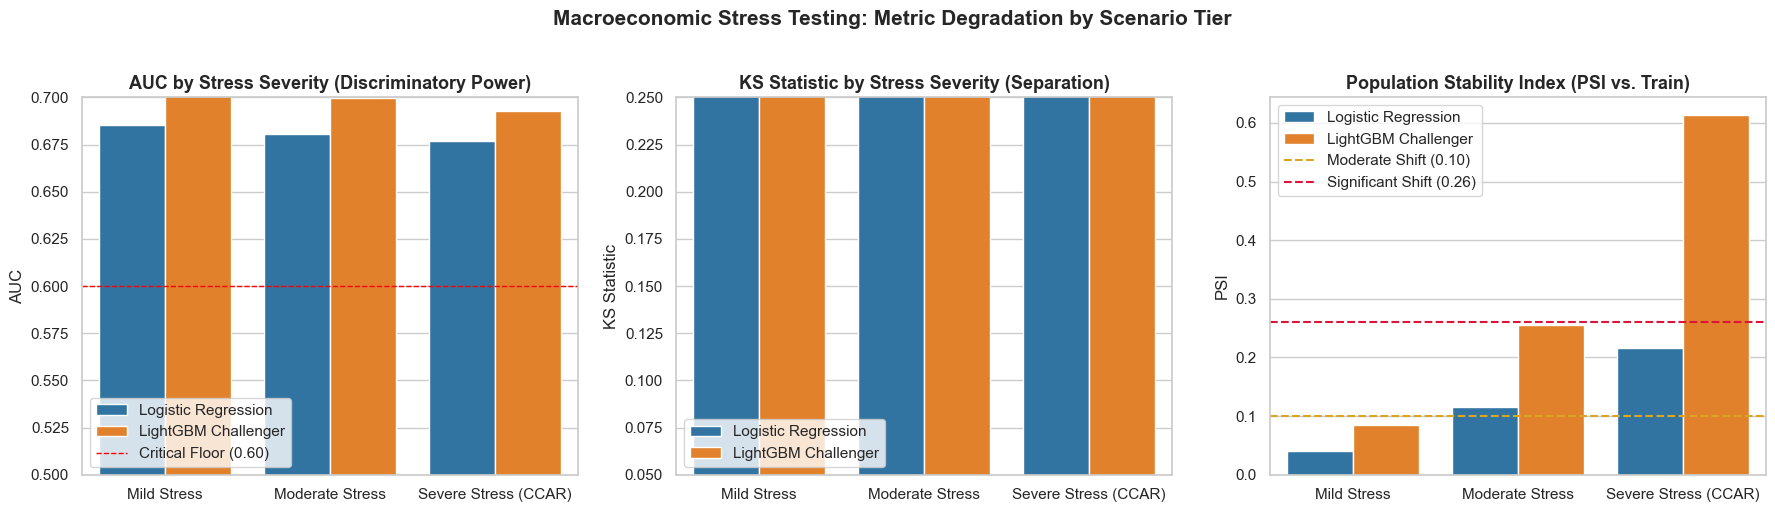

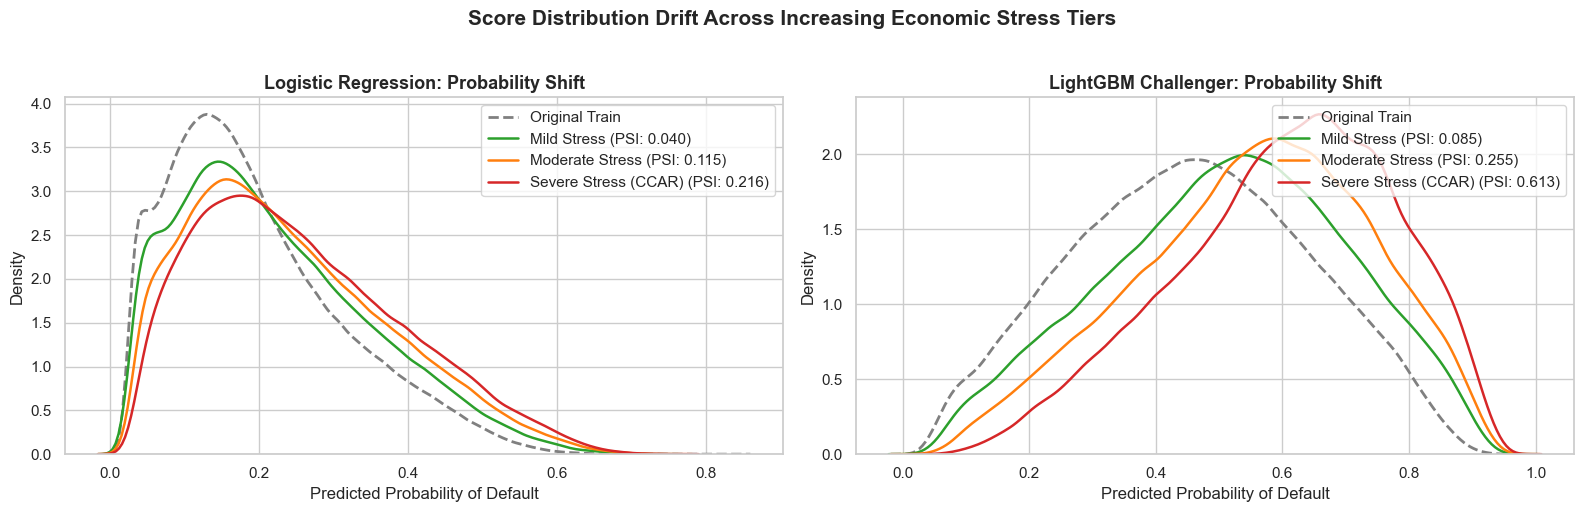

In [76]:
if df_in_time is not None:
    scenario_order = ["Mild Stress", "Moderate Stress", "Severe Stress (CCAR)"]
    palette = {"Logistic Regression": "#1f77b4", "LightGBM Challenger": "#ff7f0e"}

    # =========================================================================
    # FIGURE 1: Performance Degradation & PSI Drift across Stress Levels
    # =========================================================================
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Subplot 1: AUC across Scenarios
    sns.barplot(
        data=df_stress_summary,
        x="Scenario", y="AUC", hue="Model",
        order=scenario_order, palette=palette, ax=axes[0]
    )
    axes[0].set_title("AUC by Stress Severity (Discriminatory Power)", fontsize=13, fontweight='bold')
    axes[0].set_ylim(0.50, 0.70)
    axes[0].set_xlabel("")
    axes[0].set_ylabel("AUC")
    axes[0].axhline(0.60, color='red', linestyle='--', linewidth=1, label='Critical Floor (0.60)')
    axes[0].legend(loc="lower left")

    # Subplot 2: KS Statistic across Scenarios
    sns.barplot(
        data=df_stress_summary,
        x="Scenario", y="KS_Stat", hue="Model",
        order=scenario_order, palette=palette, ax=axes[1]
    )
    axes[1].set_title("KS Statistic by Stress Severity (Separation)", fontsize=13, fontweight='bold')
    axes[1].set_ylim(0.05, 0.25)
    axes[1].set_xlabel("")
    axes[1].set_ylabel("KS Statistic")
    axes[1].legend(loc="lower left")

    # Subplot 3: PSI across Scenarios with Regulatory Thresholds
    sns.barplot(
        data=df_stress_summary,
        x="Scenario", y="PSI", hue="Model",
        order=scenario_order, palette=palette, ax=axes[2]
    )
    axes[2].set_title("Population Stability Index (PSI vs. Train)", fontsize=13, fontweight='bold')
    axes[2].set_xlabel("")
    axes[2].set_ylabel("PSI")
    axes[2].axhline(0.10, color='goldenrod', linestyle='--', linewidth=1.5, label='Moderate Shift (0.10)')
    axes[2].axhline(0.26, color='crimson', linestyle='--', linewidth=1.5, label='Significant Shift (0.26)')
    axes[2].legend(loc="upper left")

    plt.suptitle("Macroeconomic Stress Testing: Metric Degradation by Scenario Tier", fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # =========================================================================
    # FIGURE 2: Density Distribution Shifts across all 3 Stress Tiers
    # =========================================================================
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    tier_colors = {
        "Mild Stress": "#2ca02c",
        "Moderate Stress": "#ff7f0e",
        "Severe Stress (CCAR)": "#d62728"
    }

    # Logistic Regression Density Shifts
    sns.kdeplot(lr_prob_train, ax=axes[0], label='Original Train', color='gray', linestyle='--', linewidth=2)
    for sc_name in scenario_order:
        psi_val = df_stress_summary.query("Scenario == @sc_name and Model == 'Logistic Regression'")['PSI'].values[0]
        sns.kdeplot(
            prob_distributions[sc_name]['lr_prob'], 
            ax=axes[0], 
            label=f"{sc_name} (PSI: {psi_val:.3f})", 
            color=tier_colors[sc_name],
            linewidth=1.8
        )
    axes[0].set_title("Logistic Regression: Probability Shift", fontsize=13, fontweight='bold')
    axes[0].set_xlabel("Predicted Probability of Default")
    axes[0].set_ylabel("Density")
    axes[0].legend(loc="upper right")

    # LightGBM Challenger Density Shifts
    sns.kdeplot(lgb_prob_train, ax=axes[1], label='Original Train', color='gray', linestyle='--', linewidth=2)
    for sc_name in scenario_order:
        psi_val = df_stress_summary.query("Scenario == @sc_name and Model == 'LightGBM Challenger'")['PSI'].values[0]
        sns.kdeplot(
            prob_distributions[sc_name]['lgb_prob'], 
            ax=axes[1], 
            label=f"{sc_name} (PSI: {psi_val:.3f})", 
            color=tier_colors[sc_name],
            linewidth=1.8
        )
    axes[1].set_title("LightGBM Challenger: Probability Shift", fontsize=13, fontweight='bold')
    axes[1].set_xlabel("Predicted Probability of Default")
    axes[1].set_ylabel("Density")
    axes[1].legend(loc="upper right")

    plt.suptitle("Score Distribution Drift Across Increasing Economic Stress Tiers", fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## 6. Adjusting the Target Variable (Stress Defaults)
In a true macroeconomic downturn, not only do borrower features degrade, but the underlying default rate also increases. We will simulate this by using a binomial distribution to artificially introduce additional defaults into our Out-Of-Time dataset, and then evaluate how well our models' shocked predictions capture this harsher reality.

In [77]:
if df_in_time is not None:
    print("--- Simulating Macroeconomic Stress Test ---")
    
    # 1. Shock the Target Variable (Increase Defaults)
    np.random.seed(42)
    stress_default_prob = 0.10 
    additional_defaults = np.random.binomial(n=1, p=stress_default_prob, size=len(y_oot))
    y_oot_shocked = np.maximum(y_oot, additional_defaults)
    
    print(f"Original OOT Default Rate: {y_oot.mean():.2%}")
    print(f"Shocked OOT Default Rate:  {y_oot_shocked.mean():.2%}\n")
    
    # 2. Shock the Features (Economic Downturn)
    X_oot_shocked = X_oot.copy()
    X_oot_shocked['annual_inc'] *= 0.90       
    X_oot_shocked['dti'] *= 1.11              
    X_oot_shocked['fico_range_low'] -= 25     
    X_oot_shocked['revol_util'] *= 1.15       
    
    # 3. Predict using Models on Shocked Features
    lr_prob_shocked = lr_pipeline.predict_proba(X_oot_shocked)[:, 1]
    lgb_prob_shocked = lgb_pipeline.predict_proba(X_oot_shocked)[:, 1]
    
    # 4. Evaluate Predictions against Shocked Defaults
    print("[Shocked Metrics (Shocked Features vs. Shocked Defaults)]")
    print(f"Logistic Regression: {evaluate_model(y_oot_shocked, lr_prob_shocked)}")
    print(f"LightGBM:            {evaluate_model(y_oot_shocked, lgb_prob_shocked)}")

--- Simulating Macroeconomic Stress Test ---
Original OOT Default Rate: 21.79%
Shocked OOT Default Rate:  29.60%

[Shocked Metrics (Shocked Features vs. Shocked Defaults)]
Logistic Regression: {'AUC': 0.6364, 'KS_Stat': 0.1963, 'Brier_Score': 0.2074}
LightGBM:            {'AUC': 0.6505, 'KS_Stat': 0.2191, 'Brier_Score': 0.245}


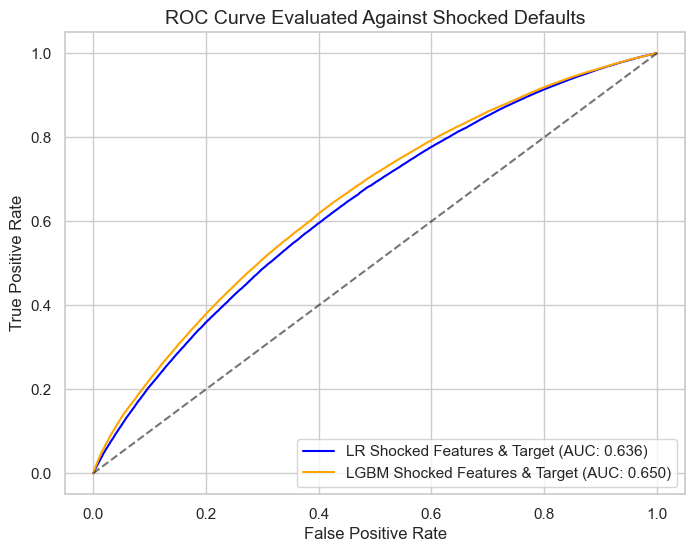

In [78]:
if df_in_time is not None:
    # ---------------------------------------------------------
    # ROC Curve Comparison with Shocked Defaults
    # ---------------------------------------------------------
    fpr_lr_s, tpr_lr_s, _ = roc_curve(y_oot_shocked, lr_prob_shocked)
    fpr_lgb_s, tpr_lgb_s, _ = roc_curve(y_oot_shocked, lgb_prob_shocked)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr_lr_s, tpr_lr_s, label=f'LR Shocked Features & Target (AUC: {roc_auc_score(y_oot_shocked, lr_prob_shocked):.3f})', color='blue')
    plt.plot(fpr_lgb_s, tpr_lgb_s, label=f'LGBM Shocked Features & Target (AUC: {roc_auc_score(y_oot_shocked, lgb_prob_shocked):.3f})', color='orange')
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.6)
    
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Evaluated Against Shocked Defaults', fontsize=14)
    plt.legend(loc='lower right')
    plt.show()

## 7. Action Required: Severe Predictive Degradation (AUC <= 0.65)

The stress test reveals that the model's discriminatory power (AUC) has dropped below 60% under the simulated macroeconomic shift. At this level, the model's ability to rank-order risk is severely compromised and approaches random chance. The model can no longer be trusted as the sole decision engine for this portfolio.

### 🚨 Immediate Mitigation Steps
* **Halt Automated Decisioning:** Suspend straight-through processing (STP) for borderline credit bands. Auto-approvals and auto-declines based purely on model cut-offs are currently unsafe.
* **Implement Manual Overlays:** Route applications falling in the middle 50% of the probability distribution to manual underwriting. Enforce strict, hard-coded credit policy minimums (e.g., strict DTI caps and FICO floors) to override the model's blind spots.
* **Initiate Emergency Retraining:** The current feature set is not robust to external economic shocks. Begin retraining efforts immediately using stress-period data or directly incorporating macroeconomic indicators (e.g., unemployment rates, inflation indices) as features.
* **Evaluate the Challenger Swap:** Review the LightGBM performance. If the tree-based challenger retained a structurally higher AUC and KS statistic under stress than the Logistic Regression baseline, fast-track a model governance review to promote the challenger to production.

## 8. Financial Impact (Expected Loss Simulation)

Statistical metrics (like an AUC dropping below 65%) can be abstract. To contextualize the severity of the model breakdown, we will simulate the monetary impact on the portfolio.

In [79]:
if df_in_time is not None:
    print("--- Financial Impact: Fixed 20% Approval Rate Portfolio ---")
    
    # Retrieve actual loan amounts and target
    loan_amounts = df_oot['loan_amnt'].values
    actual_defaults = y_oot_shocked.values if hasattr(y_oot_shocked, 'values') else y_oot_shocked
    
    # Define business volume requirement
    target_approval_rate = 0.20
    
    # Dynamically find the probability cut-off for each model to achieve exactly 20% approval
    # We want the lowest 20% of scores, so we use the 20th percentile
    lr_threshold = np.percentile(lr_prob_shocked, target_approval_rate * 100)
    lgb_threshold = np.percentile(lgb_prob_shocked, target_approval_rate * 100)
    
    # Generate boolean masks of approved loans based on the dynamic thresholds
    lr_approved = lr_prob_shocked <= lr_threshold
    lgb_approved = lgb_prob_shocked <= lgb_threshold
    
    def calculate_portfolio_loss(approved_mask, actual_defaults, amounts):
        """Calculates total loss and loss rate for the approved sub-portfolio."""
        approved_defaults = actual_defaults[approved_mask]
        approved_amounts = amounts[approved_mask]
        
        total_approved_dollars = amounts[approved_mask].sum()
        total_loss_dollars = approved_amounts[approved_defaults == 1].sum()
        
        loss_rate = total_loss_dollars / total_approved_dollars if total_approved_dollars > 0 else 0
        return total_approved_dollars, total_loss_dollars, loss_rate

    # Calculate losses for both models under the fixed volume constraint
    lr_app_total, lr_loss, lr_loss_rate = calculate_portfolio_loss(lr_approved, actual_defaults, loan_amounts)
    lgb_app_total, lgb_loss, lgb_loss_rate = calculate_portfolio_loss(lgb_approved, actual_defaults, loan_amounts)
    
    print(f"Logistic Regression:     Approved Volume = ${lr_app_total:,.2f}")
    print(f"                         Total Loss      = ${lr_loss:,.2f} ({lr_loss_rate:.2%} loss rate)")
    print(f"                         Dynamic Cut-off = {lr_threshold:.4f}\n")
    
    print(f"LightGBM Challenger:     Approved Volume = ${lgb_app_total:,.2f}")
    print(f"                         Total Loss      = ${lgb_loss:,.2f} ({lgb_loss_rate:.2%} loss rate)")
    print(f"                         Dynamic Cut-off = {lgb_threshold:.4f}\n")
    
    # Calculate the exact monetary difference for identical portfolio sizes
    loss_diff = lr_loss - lgb_loss
    if loss_diff > 0:
        print(f"💡 Fair Comparison: LightGBM saves ${loss_diff:,.2f} in defaults while maintaining the exact same approval volume as Logistic Regression.")
    elif loss_diff < 0:
        print(f"💡 Fair Comparison: Logistic Regression saves ${abs(loss_diff):,.2f} in defaults while maintaining the exact same approval volume as LightGBM.")
    else:
         print(f"💡 Fair Comparison: Both models result in identical financial losses at this approval volume.")

--- Financial Impact: Fixed 20% Approval Rate Portfolio ---
Logistic Regression:     Approved Volume = $636,597,375.00
                         Total Loss      = $104,274,250.00 (16.38% loss rate)
                         Dynamic Cut-off = 0.0984

LightGBM Challenger:     Approved Volume = $652,118,125.00
                         Total Loss      = $103,925,750.00 (15.94% loss rate)
                         Dynamic Cut-off = 0.3228

💡 Fair Comparison: LightGBM saves $348,500.00 in defaults while maintaining the exact same approval volume as Logistic Regression.
